In [3]:
# Install Kaggle
!pip install -q kaggle

# Upload kaggle.json
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"sanatkumarbaral","key":"db6f5edbbaaaacf4a13b68d939c3d6f1"}'}

In [4]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [5]:
!kaggle competitions download -c aptos2019-blindness-detection

100% 9.51G/9.51G [00:54<00:00, 189MB/s]



In [6]:
# Install Kaggle
!pip install -q kaggle

# Upload kaggle.json
from google.colab import files
files.upload()

# Setup Kaggle
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

Saving kaggle.json to kaggle (1).json


In [7]:
!kaggle competitions download -c aptos2019-blindness-detection

aptos2019-blindness-detection.zip: Skipping, found more recently modified local copy (use --force to force download)


In [8]:
!kaggle competitions download -c aptos2019-blindness-detection

aptos2019-blindness-detection.zip: Skipping, found more recently modified local copy (use --force to force download)


In [9]:
!unzip aptos2019-blindness-detection.zip

Streaming output truncated to the last 5000 lines.
  inflating: test_images/512beaada8f0.png  
  inflating: test_images/51323e9d2070.png  
  inflating: test_images/515675001b9e.png  
  inflating: test_images/515877da2def.png  
  inflating: test_images/5168ddccea88.png  
  inflating: test_images/5172c056a687.png  
  inflating: test_images/5177461f5339.png  
  inflating: test_images/51910bcb980d.png  
  inflating: test_images/51a3e9b6a1c0.png  
  inflating: test_images/51bbd82feec8.png  
  inflating: test_images/51de5fb8eccd.png  
  inflating: test_images/51e88694c81f.png  
  inflating: test_images/51f0bf8f1544.png  
  inflating: test_images/51f57fb32840.png  
  inflating: test_images/51fa42dc1415.png  
  inflating: test_images/5276ab33b7b0.png  
  inflating: test_images/52a353760f72.png  
  inflating: test_images/531937254e73.png  
  inflating: test_images/5325b1c22c61.png  
  inflating: test_images/53959e0a750b.png  
  inflating: test_images/53be22c72713.png  
  inflating: test_images/

In [10]:
import pandas as pd

df = pd.read_csv('train.csv')
df.head()

,id_code,diagnosis
0,000c1434d8d7,2
1,001639a390f0,4
2,0024cdab0c1e,1
3,002c21358ce6,0
4,005b95c28852,0


(np.float64(-0.5), np.float64(3215.5), np.float64(2135.5), np.float64(-0.5))

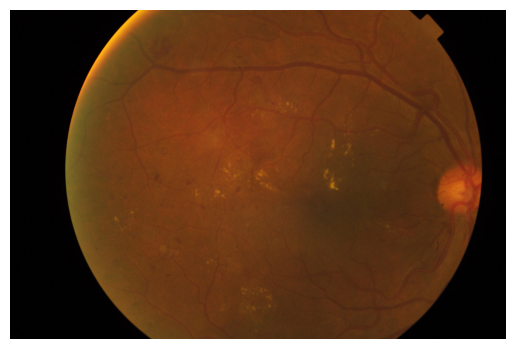

In [11]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread('train_images/' + df.iloc[0]['id_code'] + '.png')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.axis('off')

In [12]:
IMG_SIZE = 224

def preprocess_image(image_path):
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img / 255.0
    return img

In [13]:
import numpy as np

X = []
y = []

for i in range(2000):   # abhi 2000 images se start karte hain (fast testing)
    img_name = df.iloc[i]['id_code']
    label = df.iloc[i]['diagnosis']

    path = 'train_images/' + img_name + '.png'

    img = preprocess_image(path)

    X.append(img)
    y.append(label)

X = np.array(X)
y = np.array(y)

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [15]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models

base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224,224,3))

base_model.trainable = True

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dense(5, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [16]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=16
)

Epoch 1/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 81s 239ms/step - accuracy: 0.6850 - loss: 0.9391 - val_accuracy: 0.4300 - val_loss: 976.9719
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 19s 186ms/step - accuracy: 0.7538 - loss: 0.6831 - val_accuracy: 0.2850 - val_loss: 1.5880
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 19s 188ms/step - accuracy: 0.7644 - loss: 0.6543 - val_accuracy: 0.4300 - val_loss: 2.4892
Epoch 4/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 18s 181ms/step - accuracy: 0.7800 - loss: 0.6209 - val_accuracy: 0.4300 - val_loss: 1.7456
Epoch 5/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 18s 181ms/step - accuracy: 0.7856 - loss: 0.5848 - val_accuracy: 0.4300 - val_loss: 4.3041
Epoch 6/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 18s 183ms/step - accuracy: 0.8081 - loss: 0.5465 - val_accuracy: 0.4350 - val_loss: 1.7294
Epoch 7/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 19s 185ms/step - accuracy: 0.8150 - loss: 0.4758 - val_accuracy: 0.4300 - val_loss: 4.3712
Epoch 8/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 18s 184ms/step - accuracy: 0.8419 - loss: